# Convergencia y LGN, TLC

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/pedro9olivares/Bourbaki/blob/main/Matematicas-para-la-Ciencia-de-Datos/Modulo-I-Probabilidad-y-Estad%C3%ADstica/Semana_3_Convergencia_LGN_y_TLC/Convergencia_LGN_y_TLC.ipynb)

La **Ley de los Grandes Números** es uno de los pocos resultados matemáticos que garantiza que una **base de datos**, obtenida a partir de observaciones aleatorias, puede ser una buena aproximación a un resultado general.

A su vez, el **Teorema del Límite Central** nos dice que aunque las variables originales no sean normales, sus sumas y promedios sí tienden a seguir una distribución normal, a medida que aumentamos el tamaño de la muestra.

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns

# Podemos utilizar numpy para simular distribuciones...
import numpy as np

# ... o scipy.
from scipy.stats import uniform
from scipy.stats import norm

import pandas as pd
import json
import time

## Pruebas de varianza infinita

En el cuaderno pasado, vimos una heurística para determinar **varianza infinita:** plottear en log-log y revisar fit y pendiente de una regresión lineal.

Un método más estadísticamente sólido (sin sensibilidad al rango) es utilizar el estimador de Hill en el contexto de Extreme Value Theory, presente en el notebook de ese mismo nombre.

## Tipos de convergencia y Poisson

En probabilidad existen distintos conceptos de **convergencia** para una sucesión de variables aleatorias $X_n$ hacia una variable límite $X$.

Algunos de los más importantes son:

- Convergencia casi segura
- Convergencia en probabilidad
- Convergencia en distribución
- Convergencia en media ($L^1$, $L^2$, etc.)

La idea intuitiva es que, aunque las variables $X_n$ y $X$ no sean iguales, sus distribuciones se vuelven cada vez más parecidas.


Uno de los resultados clásicos más importantes es la convergencia de la **distribución Binomial** hacia la **distribución de Poisson**.

Sea

$$
X_n \sim \text{Binomial}(n,p_n)
$$

donde:

- $n \to \infty$
- $p_n \to 0$
- pero manteniendo

$$
n p_n \to \lambda
$$

con $\lambda > 0$ constante.

Entonces:

$$
X_n \xrightarrow{d} \text{Poisson}(\lambda)
$$


La distribución Binomial modela número de éxitos en $n$ experimentos independientes

Por ejemplo número de clientes que compran, número de defectos, número de accidentes, número de mutaciones, número de llamadas. En este régimen también aparece naturalmente la distribución de Poisson (modela conteos).


Cuando hay muchísimos intentos, pero cada evento individual es muy raro, la Binomial se vuelve difícil de manejar directamente.

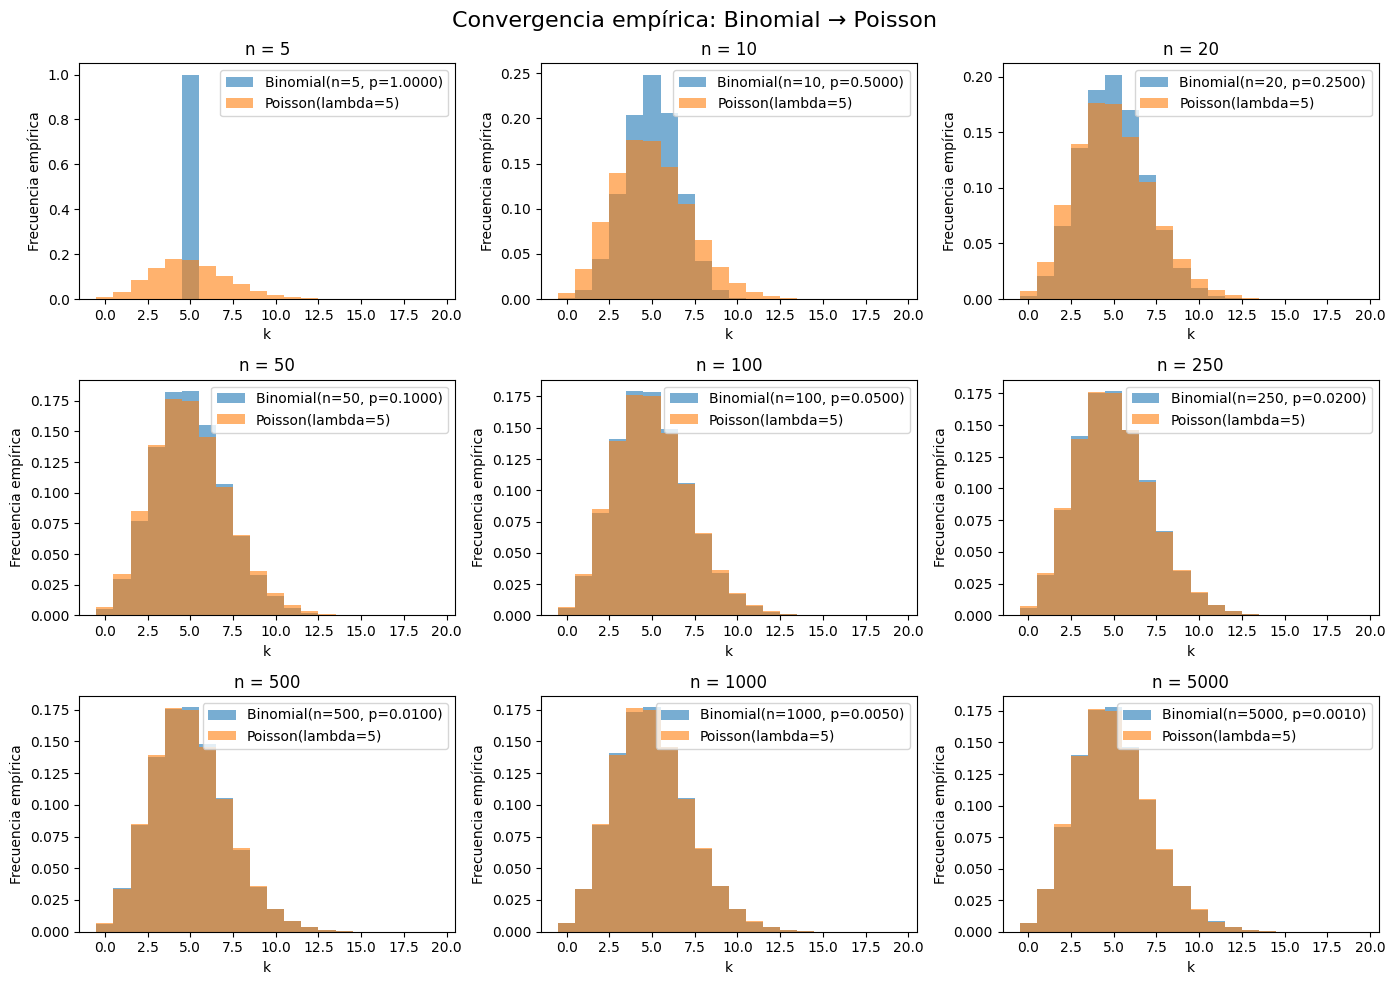

In [20]:
# Comparación visual: Binomial -> Poisson

# La idea es observar cómo, al aumentar n y reducir p,
# manteniendo lambda = n*p constante,
# la distribución Binomial converge a Poisson.

lmbda = 5
sample_size = 100_000

# Distintos valores de n
n_values = [5, 10, 20, 50, 100, 250, 500, 1000, 5000]

fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()

poisson_samples = np.random.poisson(lam=lmbda, size=sample_size)

for ax, n in zip(axes, n_values):

    # Ajustamos p para mantener lambda constante
    p = lmbda / n

    # Simulaciones
    binomial_samples = np.random.binomial(n=n, p=p, size=sample_size)

    # Valores posibles
    max_k = max(binomial_samples.max(), poisson_samples.max())
    bins = np.arange(0, max_k + 2) - 0.5

    # Histogramas normalizados
    ax.hist(
        binomial_samples,
        bins=bins,
        density=True,
        alpha=0.6,
        label=f'Binomial(n={n}, p={p:.4f})'
    )

    ax.hist(
        poisson_samples,
        bins=bins,
        density=True,
        alpha=0.6,
        label=f'Poisson(lambda={lmbda})'
    )

    ax.set_title(f'n = {n}')
    ax.set_xlabel('k')
    ax.set_ylabel('Frecuencia empírica')
    ax.legend()

plt.suptitle('Convergencia empírica: Binomial → Poisson', fontsize=16)
plt.tight_layout()
plt.show()

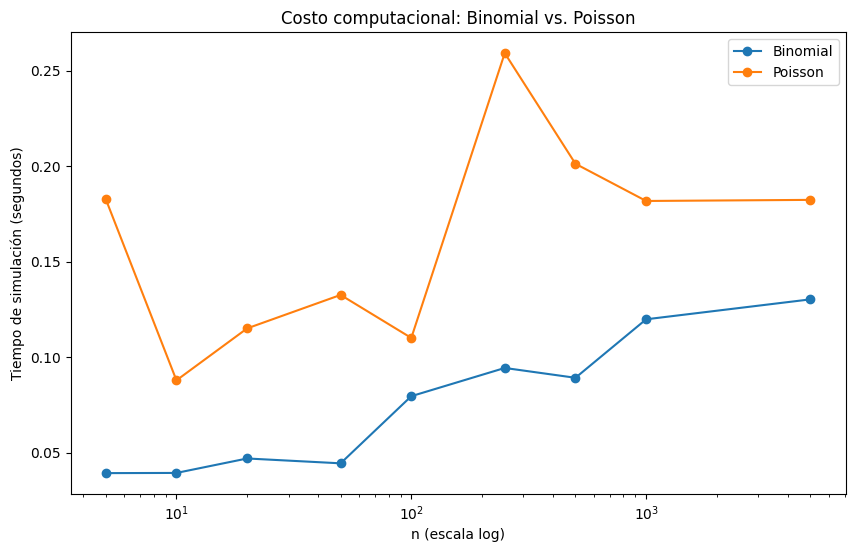

In [3]:
# Comparación de tiempo computacional

# Medimos cuánto tarda generar muestras Binomiales
# versus Poisson al incrementar n.
lmbda = 5
sample_size = 500_000

n_values = [5, 10, 20, 50, 100, 250, 500, 1000, 5000]
binomial_times = []
poisson_times = []

for n in n_values:

    p = lmbda / n

    # -------------------------
    # Tiempo Binomial
    # -------------------------
    start = time.perf_counter()

    np.random.binomial(
        n=n,
        p=p,
        size=sample_size
    )

    end = time.perf_counter()

    binomial_times.append(end - start)

    # -------------------------
    # Tiempo Poisson
    # -------------------------
    start = time.perf_counter()

    np.random.poisson(
        lam=lmbda,
        size=sample_size
    )

    end = time.perf_counter()

    poisson_times.append(end - start)

plt.figure(figsize=(10, 6))
plt.plot(
    n_values,
    binomial_times,
    marker='o',
    label='Binomial'
)
plt.plot(
    n_values,
    poisson_times,
    marker='o',
    label='Poisson'
)
plt.xscale('log')
plt.xlabel('n (escala log)')
plt.ylabel('Tiempo de simulación (segundos)')
plt.title('Costo computacional: Binomial vs. Poisson')
plt.legend()
plt.show()

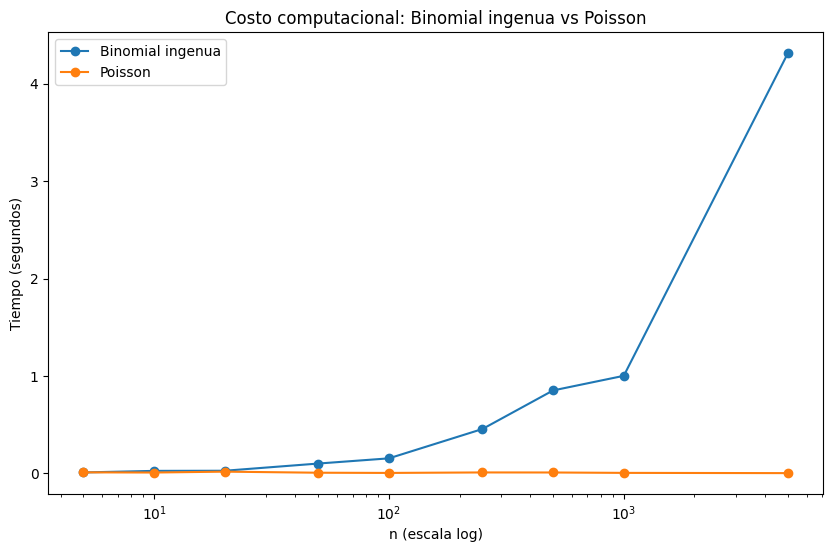

In [4]:
# Comparación de tiempo computacional: Simulación ingenua de Binomial

# Aquí simulamos la Binomial como suma explícita
# de n Bernoullis independientes.

import time

lmbda = 5
sample_size = 20_000

n_values = [5, 10, 20, 50, 100, 250, 500, 1000, 5000]
binomial_times = []
poisson_times = []

for n in n_values:

    p = lmbda / n

    # ------------------------------------------------
    # Binomial ingenua
    # ------------------------------------------------
    start = time.perf_counter()

    bernoullis = np.random.rand(sample_size, n) < p
    binomial_samples = bernoullis.sum(axis=1)

    end = time.perf_counter()

    binomial_times.append(end - start)

    # ------------------------------------------------
    # Poisson
    # ------------------------------------------------
    start = time.perf_counter()

    poisson_samples = np.random.poisson(
        lam=lmbda,
        size=sample_size
    )

    end = time.perf_counter()

    poisson_times.append(end - start)


plt.figure(figsize=(10,6))
plt.plot(
    n_values,
    binomial_times,
    marker='o',
    label='Binomial ingenua'
)
plt.plot(
    n_values,
    poisson_times,
    marker='o',
    label='Poisson'
)
plt.xscale('log')
plt.xlabel('n (escala log)')
plt.ylabel('Tiempo (segundos)')
plt.title('Costo computacional: Binomial ingenua vs Poisson')
plt.legend()
plt.show()

## La ley de los grandes números (LGN)

La Ley de los Grandes Números nos dice que el **promedio empírico** de una secuencia de variables aleatorias i.i.d., con media finita, converge al **promedio teórico**:

$$
\frac{X_1 + X_2 + \cdots + X_N}{N} \;\; \longrightarrow \;\; \mathbb{E}[X_i] \quad \text{cuando } N \to \infty
$$


In [5]:
# Ejemplo con la distribución de Poisson
#                       X ~ Poi(λ)
# Esta distribución sirve para modelar conteos de eventos

lam = 5  # tasa de ocurrencia de eventos
print("Parámetro teórico λ =", lam)

# La media teórica de una variable Poisson es igual a λ
media_teorica = lam
print("Media teórica de la distribución =", media_teorica)

# Consigamos n muestras y calculemos el promedio empírico
n_list = [10, 50, 100, 500, 50_000]

for n in n_list:
    X = np.random.poisson(lam=lam, size=n)
    media_muestral = np.sum(X) / n
    print(f"\n\tPara n={n}, la media muestral simulada fue: {media_muestral:.2f} (diferencia de {abs(media_teorica - media_muestral):.2f})")


Parámetro teórico λ = 5
Media teórica de la distribución = 5

	Para n=10, la media muestral simulada fue: 5.90 (diferencia de 0.90)

	Para n=50, la media muestral simulada fue: 5.30 (diferencia de 0.30)

	Para n=100, la media muestral simulada fue: 5.33 (diferencia de 0.33)

	Para n=500, la media muestral simulada fue: 5.00 (diferencia de 0.00)

	Para n=50000, la media muestral simulada fue: 5.01 (diferencia de 0.01)


In [6]:
# Ejemplo con la distribución Uniforme
#                       X ~ U(a, b)
# Esta distribución sirve para modelar fenómenos equiprobables

a = 0   # límite inferior
b = 1   # límite superior
print("Parámetros teóricos a =", a, ", b =", b)

# La media teórica de una variable Uniforme es (a + b) / 2
media_teorica = (a + b) / 2
print("Media teórica de la distribución =", media_teorica)

n_list = [10, 50, 100, 500, 50_000]

for n in n_list:
    X = np.random.uniform(low=a, high=b, size=n)
    media_muestral = np.sum(X) / n
    print(f"\n\tPara n={n}, la media muestral simulada fue: {media_muestral:.2f} (diferencia de {abs(media_teorica - media_muestral):.2f})")


Parámetros teóricos a = 0 , b = 1
Media teórica de la distribución = 0.5

	Para n=10, la media muestral simulada fue: 0.50 (diferencia de 0.00)

	Para n=50, la media muestral simulada fue: 0.47 (diferencia de 0.03)

	Para n=100, la media muestral simulada fue: 0.50 (diferencia de 0.00)

	Para n=500, la media muestral simulada fue: 0.50 (diferencia de 0.00)

	Para n=50000, la media muestral simulada fue: 0.50 (diferencia de 0.00)


In [7]:
# Ejemplo 1 con la distribución Pareto (α > 1, media finita)
#                       X ~ Pareto(α, x_m)
# Esta distribución sirve para modelar fenómenos tipo 80:20 (colas pesadas)

alpha = 2  # parámetro de forma
x_m = 1      # valor mínimo posible
print("Parámetros teóricos α =", alpha, ", x_m =", x_m)

# La media teórica de una variable Pareto es (α * x_m) / (α - 1), solo si α > 1
media_teorica = (alpha * x_m) / (alpha - 1)
print("Media teórica de la distribución =", media_teorica)

n_list = [10, 50, 100, 500, 50_000]

for n in n_list:
    X = (np.random.pareto(a=alpha, size=n) + 1) * x_m  # ajustamos pues numpy hace x_m = 1 por defecto
    media_muestral = np.sum(X) / n
    print(f"\n\tPara n={n}, la media muestral simulada fue: {media_muestral:.2f} (diferencia de {abs(media_teorica - media_muestral):.2f})")


Parámetros teóricos α = 2 , x_m = 1
Media teórica de la distribución = 2.0

	Para n=10, la media muestral simulada fue: 1.74 (diferencia de 0.26)

	Para n=50, la media muestral simulada fue: 2.02 (diferencia de 0.02)

	Para n=100, la media muestral simulada fue: 2.11 (diferencia de 0.11)

	Para n=500, la media muestral simulada fue: 2.27 (diferencia de 0.27)

	Para n=50000, la media muestral simulada fue: 2.00 (diferencia de 0.00)


In [8]:
# Ejemplo 2 con la distribución Pareto (α < 1, media infinita)

alpha = .5  # parámetro de forma
x_m = 1      # valor mínimo posible
print("Parámetros teóricos α =", alpha, ", x_m =", x_m)

media_teorica = (alpha * x_m) / (alpha - 1)
print("Media teórica de la distribución =", media_teorica)

n_list = [10, 50, 100, 500, 50_000]

for n in n_list:
    X = (np.random.pareto(a=alpha, size=n) + 1) * x_m
    media_muestral = np.sum(X) / n
    print(f"\n\tPara n={n}, la media muestral simulada fue: {media_muestral:.2f} (diferencia de {abs(media_teorica - media_muestral):.2f})")


Parámetros teóricos α = 0.5 , x_m = 1
Media teórica de la distribución = -1.0

	Para n=10, la media muestral simulada fue: 15.02 (diferencia de 16.02)

	Para n=50, la media muestral simulada fue: 28.44 (diferencia de 29.44)

	Para n=100, la media muestral simulada fue: 121.06 (diferencia de 122.06)

	Para n=500, la media muestral simulada fue: 705.42 (diferencia de 706.42)

	Para n=50000, la media muestral simulada fue: 61075.53 (diferencia de 61076.53)


**Comentario:**

Existen dos tipos de ley de los grandes números: **débil** y **fuerte**, dependiendo del tipo de convergencia usado.  
La ley débil utiliza convergencia en probabilidad, mientras que la ley fuerte utiliza convergencia casi segura.

Convergencia en probabilidad:  
$$
X_n \xrightarrow{P} X \quad\iff\quad \forall \,\varepsilon > 0,\; \lim_{n\to\infty} P(|X_n - X| > \varepsilon) = 0
$$

Convergencia casi segura:  
$$
X_n \xrightarrow{\text{c.s.}} X \quad\iff\quad P\left( \lim_{n\to\infty} X_n = X \right) = 1
$$

Más en: https://en.wikipedia.org/wiki/Convergence_of_random_variables


<img src="https://github.com/pedro9olivares/Bourbaki/blob/main/Matematicas-para-la-Ciencia-de-Datos/Modulo-I-Probabilidad-y-Estad%C3%ADstica/Semana_3_Convergencia_LGN_y_TLC/Convergence_in_distribution_(sum_of_uniform_rvs).gif?raw=1">

In [9]:
# Ejemplo con la distribución Bernoulli
#                       X ~ Bern(p)
# Esta distribución sirve para modelar eventos binarios (éxito/fracaso)

p = 0.5  # probabilidad de éxito
print("Parámetro teórico p =", p)

# La media teórica de una variable Bernoulli es igual a p
media_teorica = p
print("Media teórica de la distribución =", media_teorica)

# Consigamos n muestras y calculemos el promedio empírico
n_list = [10, 50, 100, 500, 50_000]

for n in n_list:
    X = np.random.binomial(n=1, p=p, size=n)
    media_muestral = np.sum(X) / n
    print(f"\n\tPara n={n}, la media muestral simulada fue: {media_muestral:.2f} (diferencia de {abs(media_teorica - media_muestral):.2f})")


Parámetro teórico p = 0.5
Media teórica de la distribución = 0.5

	Para n=10, la media muestral simulada fue: 0.40 (diferencia de 0.10)

	Para n=50, la media muestral simulada fue: 0.56 (diferencia de 0.06)

	Para n=100, la media muestral simulada fue: 0.57 (diferencia de 0.07)

	Para n=500, la media muestral simulada fue: 0.52 (diferencia de 0.02)

	Para n=50000, la media muestral simulada fue: 0.50 (diferencia de 0.00)


**Comentario**

Para $X \sim \text{Bern}(p)$, por definición:

$$
P(X=1) = p
$$

Por la Ley de los Grandes Números:

$$
\overline{X} \;\longrightarrow\; \mathbb{E}[X] = p \quad \text{cuando } n \to \infty.
$$

En otras, palabras:
$$
\overline{X} \;\longrightarrow\; P(X=1)
$$





## El teorema del límite central (TLC)

El **Teorema del Límite Central** establece que, bajo ciertas condiciones, la suma o promedio de un gran número de variables aleatorias independientes e idénticamente distribuidas se aproxima a una **distribución normal**, sin importar la distribución original de las variables.

Sean $ X_1, X_2, \dots, X_n$ i.i.d. con media $\mu = \mathbb{E}[X_i]$ y varianza $\sigma^2 = \text{Var}(X_i) < \infty$. Definimos la suma estandarizada:

$$
S_n = \frac{\sum_{i=1}^{n} X_i - n\mu}{\sigma \sqrt{n}}
$$

El TLC dice que cuando $n \to \infty$:

$$
S_n \;\;\xrightarrow{d}\;\; \mathcal{N}(0,1)
$$

Este teorema es crucial porque permite usar la distribución normal para aproximar sumas de variables aleatorias, incluso cuando estas no siguen una distribución normal.

Promedios de las muestras: [0.44585645 0.47199615 0.55607008 ... 0.46436003 0.5655506  0.49686564]


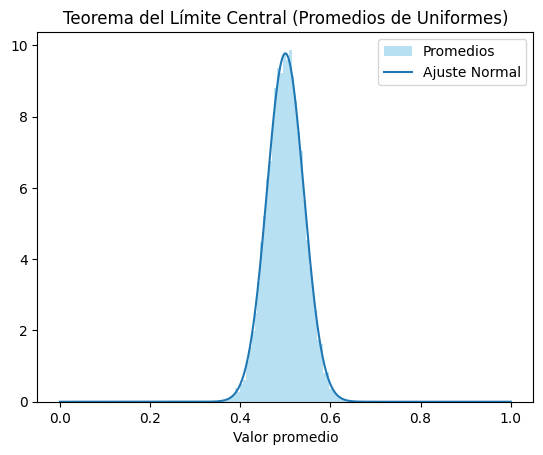

In [10]:
# TLC para suma de uniformes

# Generamos 10,000 muestras aleatorias de tamaño 50 de una distribución uniforme [0, 1]
n_samples = 10_000
sample_size = 50
uniform_samples = uniform.rvs(size=(n_samples, sample_size))

# Calculamos los promedios de cada conjunto de muestras
sample_means = uniform_samples.mean(axis=1)
print('Promedios de las muestras:',sample_means)

# Graficamos los promedios y comparamos contra una distribución normal
x = np.linspace(0, 1, 1000)
normal_fit = norm.pdf(x, loc=0.5, scale=1 / (12 * sample_size)**0.5)  # Parámetros teóricos

plt.hist(sample_means, bins=50, density=True, alpha=0.6, color='skyblue', label="Promedios")
plt.plot(x, normal_fit, label="Ajuste Normal")
plt.title("Teorema del Límite Central (Promedios de Uniformes)")
plt.xlabel("Valor promedio")
plt.legend()
plt.show()

<img src="https://github.com/pedro9olivares/Bourbaki/blob/main/Matematicas-para-la-Ciencia-de-Datos/Modulo-I-Probabilidad-y-Estad%C3%ADstica/Semana_3_Convergencia_LGN_y_TLC/IllustrationCentralTheorem.png?raw=1">

In [11]:
# TLC en un dataset real
from sklearn.datasets import fetch_california_housing

# Supongamos que este dataset es toda nuestra población
data = fetch_california_housing(as_frame=True).frame
data

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


In [12]:
# Seleccionamos una variable en la cual concentrarnos
variable = 'MedInc'
values = data[variable].values
print(f"Media 'teórica' de {variable}: ", values.mean())

Media 'teórica' de MedInc:  3.8706710029069766


In [13]:
# Particionemos en muestras de tamaño 300
sample_size = 300

# Número de submuestras que podemos extraer (floor division)
num_samples = len(values) // sample_size

# Dividimos la columna en muestras de tamaño 50
samples = np.array_split(values[:num_samples*sample_size], num_samples)

print(f"Número de muestras de tamaño {sample_size}: {len(samples)}")
print(f"\nPrimeras 5 medias muestrales:", [np.mean(s) for s in samples[:5]])

Número de muestras de tamaño 300: 68

Primeras 5 medias muestrales: [np.float64(3.1752266666666666), np.float64(3.7895543333333337), np.float64(4.004885333333333), np.float64(3.630898666666667), np.float64(3.862944333333334)]


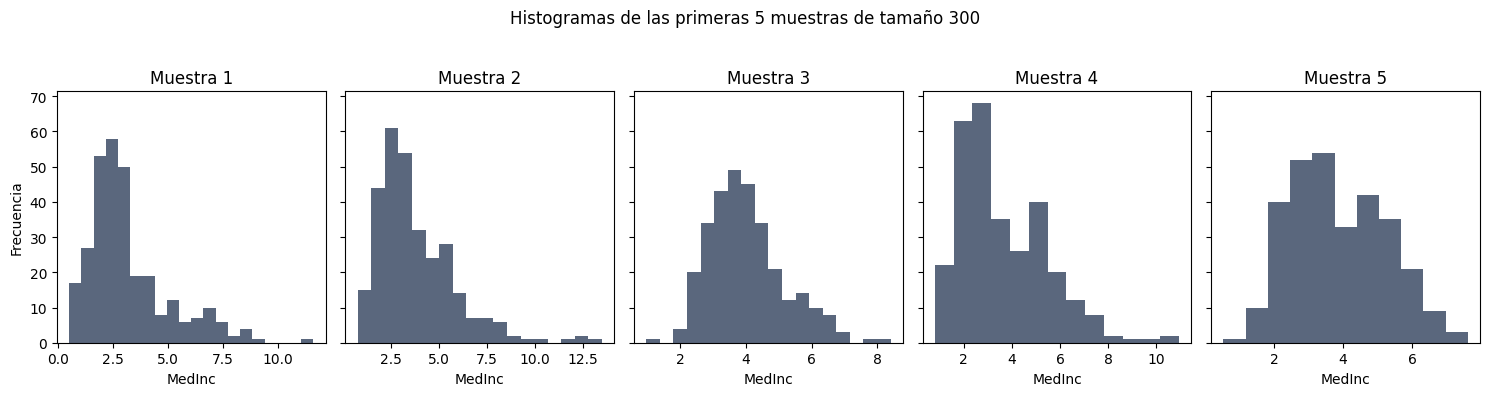

In [14]:
num_to_plot = 5
fig, axes = plt.subplots(1, num_to_plot, figsize=(15, 4), sharey=True)

for i, sample in enumerate(samples[:num_to_plot]):
    axes[i].hist(sample, bins='fd', color='#5A677D')
    axes[i].set_title(f"Muestra {i+1}")
    axes[i].set_xlabel(variable)
    if i == 0:
        axes[i].set_ylabel("Frecuencia")

plt.suptitle(f"Histogramas de las primeras {num_to_plot} muestras de tamaño {sample_size}")
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

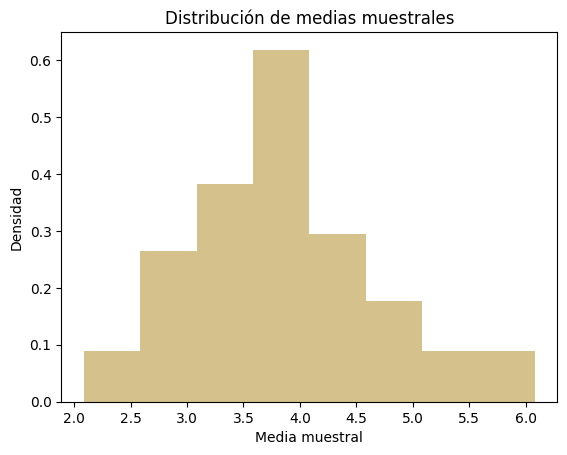

In [15]:
sample_means = np.array([np.mean(s) for s in samples])
plt.hist(sample_means, bins='fd', density=True, color='#D5C18B')
plt.title(f"Distribución de medias muestrales")
plt.xlabel("Media muestral")
plt.ylabel("Densidad")
plt.show()

# ¿Utilidad práctica?

La LGN y el TLC proporcionan la base teórica para inferir **propiedades poblacionales** a partir de **muestras**.

*LGN*

- **Encuestas de opinión o sondeos electorales:** si tomamos una muestra representativa grande de la población, la proporción de respuestas observadas se aproxima al valor real de toda la población.
- **Bases de datos financieras:** al calcular la media de rendimientos diarios de un activo a partir de muchas observaciones, podemos aproximar el rendimiento esperado del activo.
- **Control de calidad:** al medir defectos en una línea de producción con suficientes unidades muestreadas, la proporción de defectuosos converge al verdadero porcentaje de defectos.

La LGN justifica el uso de **estadísticos muestrales como estimadores consistentes**, porque sabemos que con más datos nos acercamos al parámetro poblacional.

---

*TLC*

- **Intervalos de confianza y pruebas de hipótesis:** al calcular la media de una muestra grande, podemos usar la aproximación normal para construir intervalos de confianza o realizar tests.
- **Machine learning:** al sumar errores o gradientes en algoritmos estocásticos, la distribución de esos promedios tiende a normal, facilitando el análisis y ajuste de parámetros.

El TLC respalda la **aplicación de técnicas paramétricas** basadas en normalidad, incluso cuando la población original no es normal, siempre que la muestra sea suficientemente grande.

# TLC generalizado

Cuando no hay varianza finita, está el **Teorema del Límite Central Generalizado** que establece que la suma normalizada de variables i.i.d converge en distribución a una **distribución estable** en lugar de una normal.

Estas distribuciones estables incluyen a la **normal** como un caso particular ($ \alpha = 2 $), pero también pueden tener **colas muy pesadas** y **varianza infinita** ($ \alpha < 2 $).
